# Evolutsiooni simulatsioon – lauamängu tulemuste analüüs

Selles analüüsis uuritakse jäneste populatsiooni evolutsiooni simuleerivat lauamängu. Mängu käigus jälgiti **kolme populatsiooni** seitsme generatsiooni vältel. Iga jänes koosneb **kahest alleelist**:

| Alleel | Tähis | Tähendus |
|--------|-------|----------|
| Must alleel | A1 | Määrab jänese karvavärvi (must) |
| Valge alleel | A2 | Määrab jänese karvavärvi (valge) |
| Hall alleel | A3 | Ilmus mutatsiooni teel alates 3. generatsioonist |

Jäneste fenotüüp sõltub alleelide kombinatsioonist:
- **Kaks musta alleeli** → must jänes
- **Kaks valget alleeli** → valge jänes
- **Must + valge** → hall jänes (osaline dominantsus / kodominantsus)
- **Hall alleel (A3)** osaleb samuti halli värvuse tekitamises

---
*Andmed: tulemused.xlsx | Simulatsioon: 3 populatsiooni × 7 generatsiooni*

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Andmete sisestamine ──────────────────────────────────────────────────────
generations = ['I', 'II', 'III', 'IV', 'V', 'VI', 'VII']
gen_num = [1, 2, 3, 4, 5, 6, 7]

data = {
    'Pop1': {
        'A1':    [0.491, 0.491, 0.375, 0.370, 0.363, 0.258, 0.164],
        'A2':    [0.509, 0.509, 0.395, 0.408, 0.402, 0.450, 0.522],
        'A3':    [0.000, 0.000, 0.230, 0.222, 0.235, 0.292, 0.314],
        'must':  [203, 200, 160, 122,  96,  80,  66],
        'valge': [ 77,  79,  56,  60,  35,  64, 108],
        'hall':  [  0,   0, 141, 102,  84, 118, 164],
        'kokku': [280, 279, 355, 281, 209, 262, 335],
    },
    'Pop2': {
        'A1':    [0.451, 0.455, 0.368, 0.374, 0.384, 0.258, 0.193],
        'A2':    [0.549, 0.545, 0.443, 0.415, 0.378, 0.418, 0.449],
        'A3':    [0.000, 0.000, 0.188, 0.211, 0.239, 0.324, 0.358],
        'must':  [158, 164, 138, 101,  74,  65,  47],
        'valge': [ 86,  81,  65,  50,  32,  41,  68],
        'hall':  [  0,   0,  97,  84,  70, 107, 121],
        'kokku': [244, 245, 301, 234, 173, 211, 235],
    },
    'Pop3': {
        'A1':    [0.543, 0.521, 0.402, 0.371, 0.360, 0.264, 0.177],
        'A2':    [0.457, 0.479, 0.374, 0.386, 0.389, 0.467, 0.555],
        'A3':    [0.000, 0.000, 0.224, 0.243, 0.251, 0.269, 0.268],
        'must':  [228, 208, 171, 125,  94,  81,  76],
        'valge': [ 52,  72,  58,  46,  40,  72, 138],
        'hall':  [  0,   0, 137, 115,  87, 118, 141],
        'kokku': [280, 280, 361, 284, 220, 265, 357],
    },
}

# Muuda DataFrame-ideks
dfs = {pop: pd.DataFrame(vals, index=generations) for pop, vals in data.items()}

# Värviskeem
POP_COLORS   = {'Pop1': '#E07B39', 'Pop2': '#3A86C8', 'Pop3': '#5BAD6F'}
ALLELE_COLORS = {'A1': '#2d2d2d', 'A2': '#f5f0e8', 'A3': '#8c8c8c'}
RABBIT_COLORS = {'must': '#2d2d2d', 'valge': '#e8e0d0', 'hall': '#9e9e9e'}

print("Andmed laaditud. Populatsioonide ülevaade:")
for pop, df in dfs.items():
    print(f"\n{pop}:")
    print(df[['A1','A2','A3','must','valge','hall','kokku']].to_string())

Andmed laaditud. Populatsioonide ülevaade:

Pop1:
        A1     A2     A3  must  valge  hall  kokku
I    0.491  0.509  0.000   203     77     0    280
II   0.491  0.509  0.000   200     79     0    279
III  0.375  0.395  0.230   160     56   141    355
IV   0.370  0.408  0.222   122     60   102    281
V    0.363  0.402  0.235    96     35    84    209
VI   0.258  0.450  0.292    80     64   118    262
VII  0.164  0.522  0.314    66    108   164    335

Pop2:
        A1     A2     A3  must  valge  hall  kokku
I    0.451  0.549  0.000   158     86     0    244
II   0.455  0.545  0.000   164     81     0    245
III  0.368  0.443  0.188   138     65    97    301
IV   0.374  0.415  0.211   101     50    84    234
V    0.384  0.378  0.239    74     32    70    173
VI   0.258  0.418  0.324    65     41   107    211
VII  0.193  0.449  0.358    47     68   121    235

Pop3:
        A1     A2     A3  must  valge  hall  kokku
I    0.543  0.457  0.000   228     52     0    280
II   0.521  0.479 

## 1. Alleelide sageduste muutus generatsioonide vältel

Järgnev joonis näitab, kuidas iga alleeli (A1 – must, A2 – valge, A3 – hall) osakaal muutus seitsme generatsiooni jooksul **kõigis kolmes populatsioonis**.

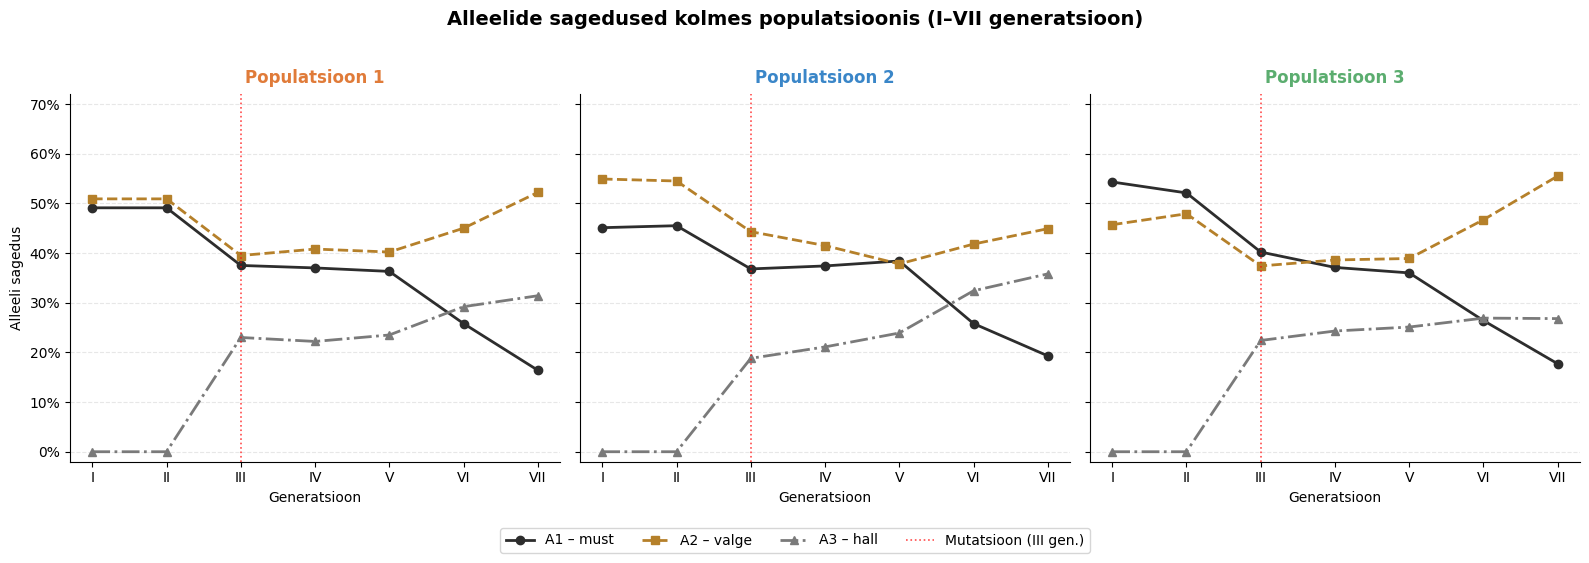

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
fig.suptitle('Alleelide sagedused kolmes populatsioonis (I–VII generatsioon)',
             fontsize=14, fontweight='bold', y=1.02)

allele_styles = {
    'A1': {'color': '#2d2d2d', 'marker': 'o',  'label': 'A1 – must',  'linestyle': '-'},
    'A2': {'color': '#b5802a', 'marker': 's',  'label': 'A2 – valge', 'linestyle': '--'},
    'A3': {'color': '#7a7a7a', 'marker': '^',  'label': 'A3 – hall',  'linestyle': '-.'},
}

pop_labels = {'Pop1': 'Populatsioon 1', 'Pop2': 'Populatsioon 2', 'Pop3': 'Populatsioon 3'}

for ax, (pop, df) in zip(axes, dfs.items()):
    for allele, style in allele_styles.items():
        ax.plot(gen_num, df[allele], color=style['color'], marker=style['marker'],
                linestyle=style['linestyle'], linewidth=2, markersize=6, label=style['label'])
    ax.axvline(x=3, color='red', linestyle=':', linewidth=1.2, alpha=0.7, label='Mutatsioon (III gen.)')
    ax.set_title(pop_labels[pop], fontsize=12, fontweight='bold',
                 color=POP_COLORS[pop], pad=8)
    ax.set_xlabel('Generatsioon', fontsize=10)
    ax.set_xticks(gen_num)
    ax.set_xticklabels(generations)
    ax.set_ylim(-0.02, 0.72)
    ax.set_yticks([0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7])
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[0].set_ylabel('Alleeli sagedus', fontsize=10)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=4, fontsize=10,
           bbox_to_anchor=(0.5, -0.08), frameon=True)
plt.tight_layout()
plt.savefig('alleelide_sagedused.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Kolme populatsiooni alleelisageduste võrdlus

Järgnev graafik asetab kõik kolm populatsiooni samale teljestikule, et näha erinevusi ja sarnasusi alleelide sageduste muutuses.

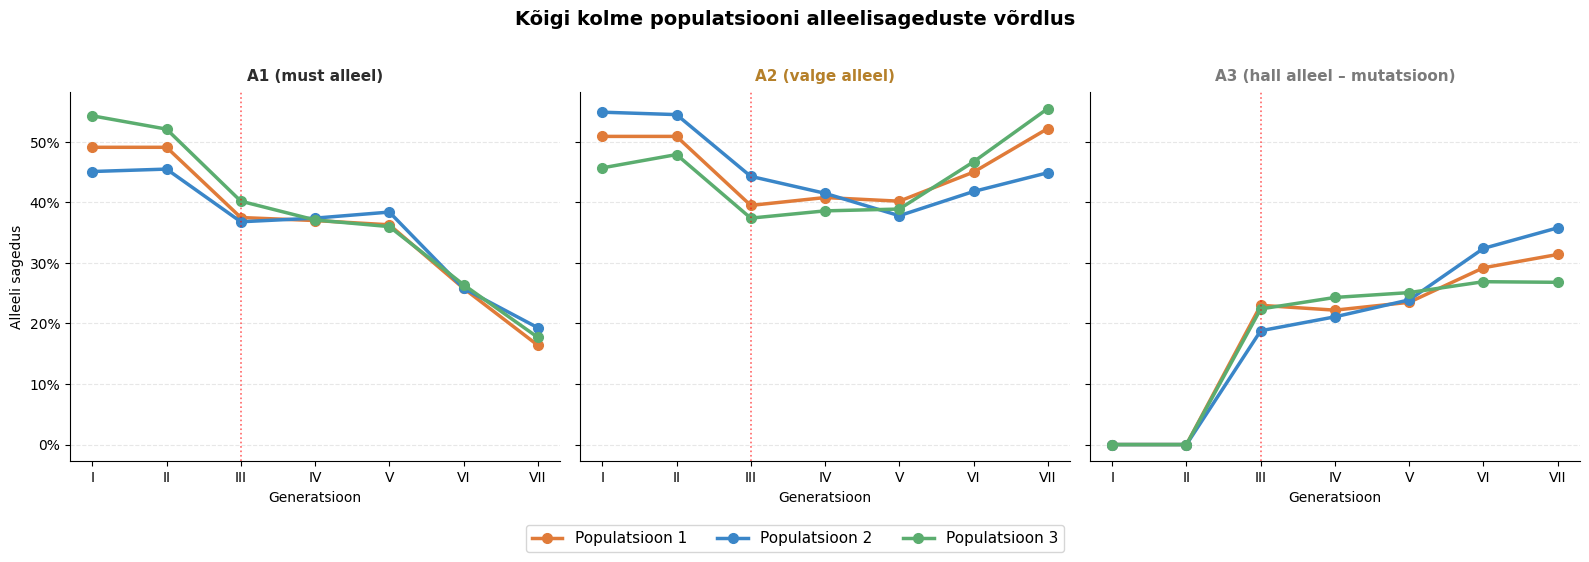

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
fig.suptitle('Kõigi kolme populatsiooni alleelisageduste võrdlus',
             fontsize=14, fontweight='bold', y=1.02)

allele_titles = {'A1': 'A1 (must alleel)', 'A2': 'A2 (valge alleel)', 'A3': 'A3 (hall alleel – mutatsioon)'}
allele_base_colors = {'A1': '#2d2d2d', 'A2': '#b5802a', 'A3': '#7a7a7a'}

for ax, (allele, title) in zip(axes, allele_titles.items()):
    for pop in ['Pop1', 'Pop2', 'Pop3']:
        ax.plot(gen_num, dfs[pop][allele],
                color=POP_COLORS[pop], marker='o', linewidth=2.5,
                markersize=7, label=pop_labels[pop])
    ax.axvline(x=3, color='red', linestyle=':', linewidth=1.2, alpha=0.6)
    ax.set_title(title, fontsize=11, fontweight='bold',
                 color=allele_base_colors[allele], pad=8)
    ax.set_xlabel('Generatsioon', fontsize=10)
    ax.set_xticks(gen_num)
    ax.set_xticklabels(generations)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[0].set_ylabel('Alleeli sagedus', fontsize=10)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, fontsize=11,
           bbox_to_anchor=(0.5, -0.08), frameon=True)
plt.tight_layout()
plt.savefig('populatsioonide_vordlus.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Jäneste arv fenotüüpide kaupa (virntulpdiagramm)

Järgnev virntulpdiagramm kujutab iga generatsiooni jäneste **absoluutarvude** jaotust fenotüüpide (must, hall, valge) kaupa kolmes populatsioonis.

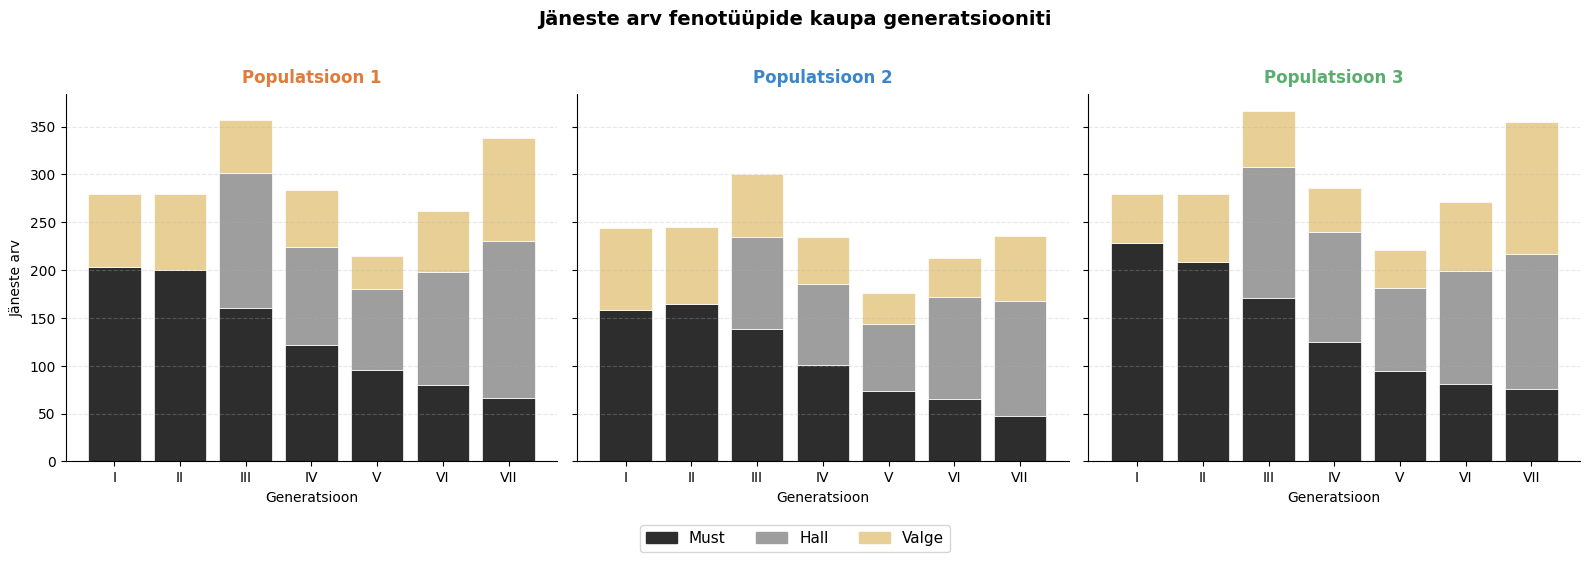

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
fig.suptitle('Jäneste arv fenotüüpide kaupa generatsiooniti',
             fontsize=14, fontweight='bold', y=1.02)

bar_colors = {'must': '#2d2d2d', 'hall': '#9e9e9e', 'valge': '#e8cf96'}

for ax, (pop, df) in zip(axes, dfs.items()):
    x = np.arange(len(generations))
    bottom = np.zeros(len(generations))
    for phenotype in ['must', 'hall', 'valge']:
        bars = ax.bar(x, df[phenotype], bottom=bottom,
                      color=bar_colors[phenotype],
                      edgecolor='white', linewidth=0.5,
                      label=phenotype.capitalize())
        bottom += df[phenotype].values

    ax.set_title(pop_labels[pop], fontsize=12, fontweight='bold',
                 color=POP_COLORS[pop], pad=8)
    ax.set_xlabel('Generatsioon', fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels(generations)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[0].set_ylabel('Jäneste arv', fontsize=10)
handles = [mpatches.Patch(color=bar_colors[p], label=p.capitalize())
           for p in ['must', 'hall', 'valge']]
fig.legend(handles=handles, loc='lower center', ncol=3, fontsize=11,
           bbox_to_anchor=(0.5, -0.08), frameon=True)
plt.tight_layout()
plt.savefig('fenotyyp_arvud.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Populatsioonide suurus generatsiooniti

Populatsiooni suurus on oluline geenitriivi ulatuse mõistmiseks – mida väiksem on populatsioon, seda tugevam on juhuslike kõikumiste mõju.

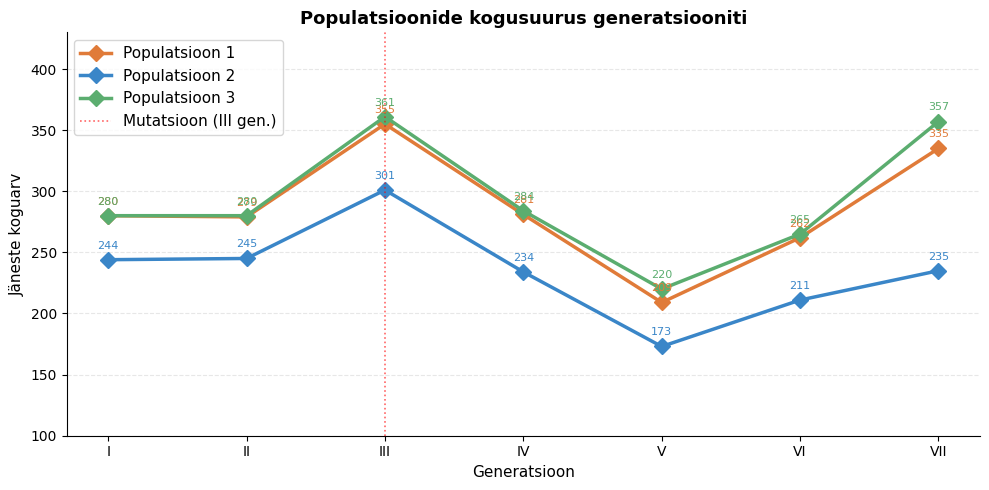

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))

for pop in ['Pop1', 'Pop2', 'Pop3']:
    ax.plot(gen_num, dfs[pop]['kokku'],
            color=POP_COLORS[pop], marker='D', linewidth=2.5,
            markersize=8, label=pop_labels[pop])
    # Arvud punktide kohal
    for g, n in zip(gen_num, dfs[pop]['kokku']):
        ax.annotate(str(n), (g, n), textcoords='offset points',
                    xytext=(0, 8), ha='center', fontsize=8,
                    color=POP_COLORS[pop])

ax.axvline(x=3, color='red', linestyle=':', linewidth=1.2, alpha=0.6,
           label='Mutatsioon (III gen.)')
ax.set_title('Populatsioonide kogusuurus generatsiooniti',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Generatsioon', fontsize=11)
ax.set_ylabel('Jäneste koguarv', fontsize=11)
ax.set_xticks(gen_num)
ax.set_xticklabels(generations)
ax.set_ylim(100, 430)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('populatsiooni_suurus.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Evolutsiooniliste mõistete selgitus lauamängu tulemuste põhjal

---

### 🔬 Mutatsiooniline muutlikkus

**Mutatsiooniline muutlikkus** on pärilike muutuste teke geenides ehk DNA järjestuses, mille tulemusel tekib uus alleel, mida populatsioonis varem polnud.

**Lauamängus:** Esimese kahe generatsiooni jooksul (I ja II) esines ainult kaks alleeli – **A1 (must)** ja **A2 (valge)**. Alates **III generatsioonist** ilmus mängu uus hallide alleelide grupp **A3**, mis sümboliseerib just mutatsioonilist muutlikkust. Mutatsioon andis populatsioonile uue geneetilise variandi, millest edaspidi sai loodusliku valiku ja muude jõudude "tooraine".

| Populatsioon | A3 sagedus III gen. | A3 sagedus VII gen. |
|---|---|---|
| Populatsioon 1 | 23,0 % | **31,4 %** |
| Populatsioon 2 | 18,8 % | **35,8 %** |
| Populatsioon 3 | 22,4 % | **26,8 %** |

Kõigis kolmes populatsioonis kasvas A3 osakaal pärast mutatsiooni ilmumist pidevalt – uus alleel levis populatsioonis edasi.

---

### 🔀 Kombinatiivne muutlikkus

**Kombinatiivne muutlikkus** tekib sugulise paljunemise käigus, kui vanemalt pärit alleelidest moodustuvad uued kombinatsioonid järglastel. See ei loo uusi alleele, kuid loob lõputult uusi genotüüpikombinatsioone.

**Lauamängus:** Kui hallid alleelid (A3) lisandusid III generatsioonis, muutus võimalike genotüübikombinatsioonide arv hüppeliselt. Nüüd sai tekkida kombinatsioone: A1A1, A1A2, A1A3, A2A2, A2A3, A3A3 – see on kombinatiivne muutlikkus töös. Mängu käigus "paariti" jäneseid, mille tulemusel tekkisid uued alleelide kombinatsioonid. Just see selgitab, miks kõigi kolme populatsiooni struktuuri muutused ei kulge identsel kujul – iga paardumisprotsess on kombinatoorselt unikaalne.

---

### 🌊 Geenivool

**Geenivool** on alleelide liikumine ühest populatsioonist teise, kui isendid rändavad ja paljunevad uues populatsioonis. See ühtlustab eri populatsioonide vahelist geneetilist erinevust.

**Lauamängus:** Kolme populatsiooni alleelisagedused on alguses erinevad, kuid näitavad sarnaseid trende – eriti A1 (must) vähenemisel ja A3 (hall) kasvamisel. See sarnane suund võib vihjata et mängijad tegid sarnaseid valikuid (analoogselt geeenivoolu efektile), kuid ka sellele, et kui need populatsioonid omavahel suhtleksid, looks geenivool veelgi suurema ühtlustamise. Reaalses elus takistaksid geenivoogu geograafilised barjäärid (mäed, jõed), inimtekkeline elupaikade killustatus vms.

---

### 🎲 Geenitriiv

**Geenitriiv** on alleelisageduse juhuslik muutus, mis on eriti tugev väikestes populatsioonides. See võib viia mingite alleelide kadumise või fikseerumiseni ka siis, kui neil pole selget kohastumuslikku eelist.

**Lauamängus:** Vaadates täpsemalt III–V generatsiooni, kus populatsioonil olid väiksemad arvud (näiteks Pop2 V gen.: ainult **173 isendit**, Pop1 V gen.: **209 isendit**), on geenitriivi mõju kõige tõenäolisem. Geenitriiv selgitab osaliselt, miks alleelisagedused kõiguvad mõnes generatsioonis ebamõistlikult palju – näiteks Pop1-s langeb A1 sagedus VI generatsiooniks järsult 36,3%-lt 25,8%-ni (langus ~10,5%), samas kui Pop2-s samas generatsioonis langeb see samavõrra (38,4% → 25,8%). See üheaegne sarnane kõikumine viitab pigem ühisele valikule (vt looduslik valik), aga aju suuruse erinevus generatsioonides näitab potentsiaalset geenitriivi rolli.

**Väikseimad populatsioonid (potentsiaalne geenitriiv):**
- Pop2 – V generatsioon: **173 isendit** (väikseim kogu mängus)
- Pop1 – V generatsioon: **209 isendit**
- Pop3 – V generatsioon: **220 isendit**

---

### 🌿 Looduslik valik

**Looduslik valik** on protsess, mille käigus ellujäämisel ja paljunemisel eelisseisundis olevate isendite tunnused (ja neid kodeerivad alleelid) kanduvad edasi sagedamini. Kohastumus on tunnuste sobivus keskkonnatingimustega.

**Lauamängus:** Loodusliku valiku mõju on nähtav **must alleeli (A1) järjepideva vähenemisena** kõigis kolmes populatsioonis – see poleks juhuslik juhul, kui see toimuks üheaegselt ja üheselt kõikides populatsioonides:

| Generatsioon | Pop1 A1 | Pop2 A1 | Pop3 A1 |
|---|---|---|---|
| I | 49,1 % | 45,1 % | 54,3 % |
| IV | 37,0 % | 37,4 % | 37,1 % |
| VII | **16,4 %** | **19,3 %** | **17,7 %** |

Kõigis kolmes populatsioonis väheneb must alleel (A1) selgelt ja järjepidevalt I–VII generatsioonini. See viitab, et **mustad jänesed olid ebasoodsas olukorras** – näiteks kiskjad leidsid nad kergemini üles (kui taust oli hele). Samal ajal **kasvas hall alleel (A3)** ning **valge alleel (A2) püsis stabiilsemana** – viimane isegi kasvas VII generatsiooniks oluliselt (Pop1: 50,9% → 52,2%; Pop3: 45,7% → 55,5%). See on klassikaline loomuliku valiku näide: ebasoodne fenotüüp (must) elimineeritakse, soodsam (hall/valge) saab eelise.

---

## 6. Kokkuvõte

Lauamängu tulemused peegeldavad viit olulist evolutsioonijõudu:

| Mõiste | Ilming mängus |
|---|---|
| **Mutatsiooniline muutlikkus** | Hall alleel A3 ilmus III generatsioonis de novo |
| **Kombinatiivne muutlikkus** | Uued genotüübikombinatsioonid A3 lisandumisega |
| **Geenivool** | Kolme populatsiooni sarnased trendid (kui oleks vahetust) |
| **Geenitriiv** | Kõikumised väiksemates populatsioonides (eriti V gen.) |
| **Looduslik valik** | A1 (must) järjepidev vähenemine kõigis populatsioonides |

Kõige selgemalt ilmneb **looduslik valik** (must alleeli süstemaatiline kadu) ja **mutatsiooniline muutlikkus** (hall alleeli äkiline ilmumine III generatsioonis). **Geenitriiv** on kõige tugevam väikseima populatsiooni (Pop2, V gen.) juures. Kuna populatsioonid on eraldiseisvad, ei esine reaalset geeenivoogu – kuid sarnased trendid näitavad, et kui geenivool võimaldatud oleks, liiguks ta populatsioonide ühtlustamise suunas.